In [3]:
import yfinance as yf 
import pandas as pd 
import matplotlib.pyplot as plt 


In [4]:
tickers = {"appl", "msft", "spy" } 


In [5]:
tickers = ["AAPL", "MSFT", "^GSPC"]

prices = yf.download(tickers, start="2020-01-01")["Close"]

prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,^GSPC
Date,,,
2020-01-02,72.400505,152.158371,3257.850098
2020-01-03,71.696640,150.263718,3234.850098
2020-01-06,72.267944,150.652191,3246.280029
2020-01-07,71.928047,149.278534,3237.179932
2020-01-08,73.085083,151.656311,3253.050049


In [6]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AAPL,MSFT,^GSPC
Date,,,
2020-01-03,-0.009722,-0.012452,-0.007060
2020-01-06,0.007968,0.002585,0.003533
2020-01-07,-0.004703,-0.009118,-0.002803
2020-01-08,0.016086,0.015928,0.004902
2020-01-09,0.021241,0.012493,0.006655


In [7]:
returns.mean()

Ticker
AAPL     0.001029
MSFT     0.000823
^GSPC    0.000582
dtype: float64

In [8]:
returns.std()

Ticker
AAPL     0.019848
MSFT     0.018743
^GSPC    0.013010
dtype: float64

In [9]:
sharpe = returns.mean() / returns.std()
sharpe

Ticker
AAPL     0.051870
MSFT     0.043930
^GSPC    0.044754
dtype: float64

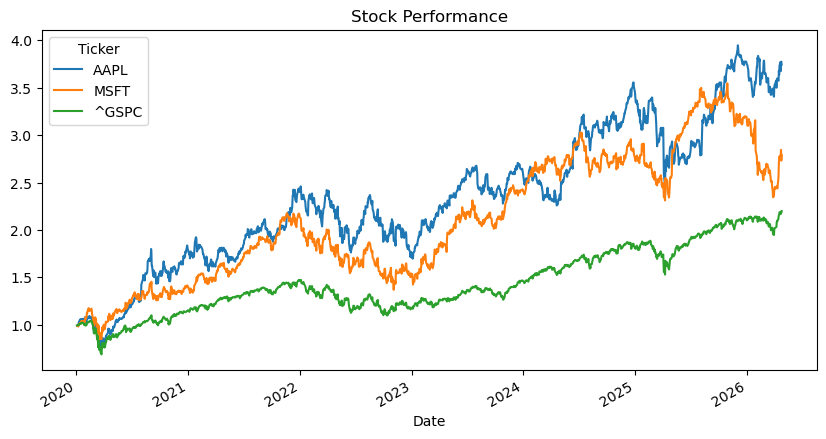

In [10]:
(1 + returns).cumprod().plot(figsize=(10,5))
plt.title("Stock Performance")
plt.show() 

[*********************100%***********************]  3 of 3 completed


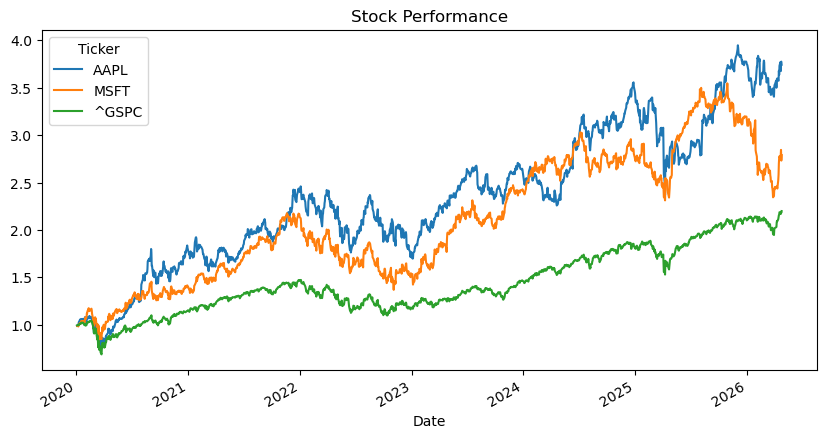

In [11]:
# 1. Import
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 2. Data
tickers = ["AAPL", "MSFT", "^GSPC"]
prices = yf.download(tickers, start="2020-01-01")["Close"]

# 3. Returns
returns = prices.pct_change().dropna()

# 4. Sharpe
sharpe = returns.mean() / returns.std()

# 5. Plot
(1 + returns).cumprod().plot(figsize=(10,5))
plt.title("Stock Performance")
plt.show()

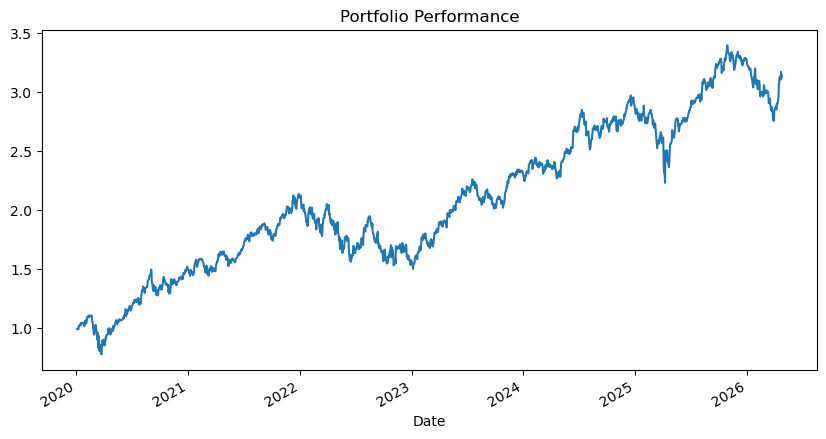

In [12]:
weights = [0.4, 0.4, 0.2]  # AAPL, MSFT, S&P

portfolio_returns = returns.dot(weights)

(1 + portfolio_returns).cumprod().plot(figsize=(10,5))
plt.title("Portfolio Performance")
plt.show()

In [13]:
annual_return = returns.mean() * 252
annual_volatility = returns.std() * (252 ** 0.5)

summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe
})

summary

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.259434,0.315073,0.051870
MSFT,0.207490,0.297531,0.043930
^GSPC,0.146731,0.206532,0.044754


In [14]:
cumulative_returns = (1 + returns).cumprod()

running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns / running_max) - 1

max_drawdown = drawdown.min()
max_drawdown

Ticker
AAPL    -0.333605
MSFT    -0.371485
^GSPC   -0.339250
dtype: float64

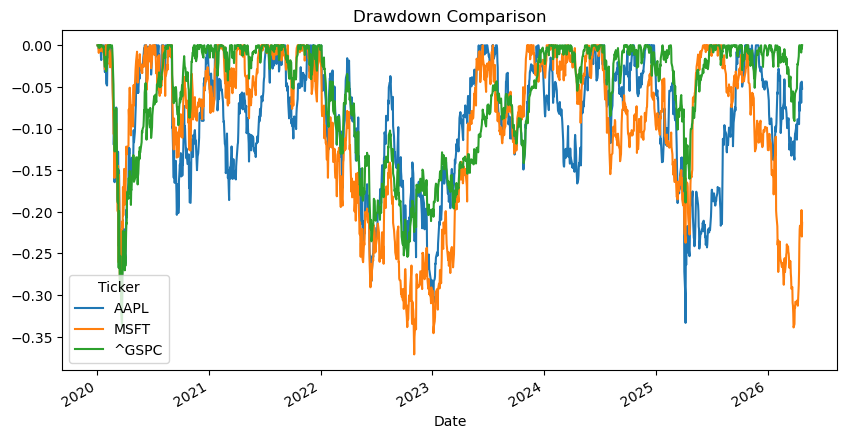

In [15]:
drawdown.plot(figsize=(10,5))
plt.title("Drawdown Comparison")
plt.show()